# Example of running a band structure workchain

Prerequsites: you may need sumo and seekpath for generating the band structure pathway install with 

```bash
pip install sumo seekpath
```

## Load the necessary AiiDA environment

The cell below will use an temporary in-memory AiiDA profile. All results will be destroyed once the session close.

In actual production environment you need:

```
%load_ext aiida
%aiida
```

instead.

In [2]:
%load_ext aiida
%aiida

The aiida extension is already loaded. To reload it, use:
  %reload_ext aiida


Loaded AiiDA DB environment - profile name: bit.

In [3]:
# pylint: disable=too-many-arguments

import numpy as np
from aiida.engine import submit
from aiida.plugins import DataFactory, WorkflowFactory

First, setup a Silicon structure. 

In addition to the methods below, one may also convert `ase.Atoms` and `pymatgen.core.Structure` with `orm.StructureData(ase=obj)` or `orm.StructureData(pymatgen=obj)`.

In [4]:
dict_data = DataFactory('core.dict')
kpoints_data = DataFactory('core.array.kpoints')


def get_structure():
    """
    Set up Si primitive cell

    Si
       5.431
         0.0000000000000000    0.5000000000000000    0.5000000000000000
         0.5000000000000000    0.0000000000000000    0.5000000000000000
         0.5000000000000000    0.5000000000000000    0.0000000000000000
    Si
       2
    Direct
      0.8750000000000000  0.8750000000000000  0.8750000000000000
      0.1250000000000000  0.1250000000000000  0.1250000000000000

    """

    structure_data = DataFactory('core.structure')
    alat = 5.431
    lattice = np.array([[0.5, 0, 0.5], [0.5, 0.5, 0], [0, 0.5, 0.5]]) * alat
    structure = structure_data(cell=lattice)
    for pos_direct in ([0.875, 0.875, 0.875], [0.125, 0.125, 0.125]):
        pos_cartesian = np.dot(pos_direct, lattice)
        structure.append_atom(position=pos_cartesian, symbols='Si')
    return structure

### The easiest way of setting up an calculation is to use a `BuilderUpdater`

The `BuilderUpdater` is a shortcut for setting calculation with preset INCAR tags and kpoints etc.
It operates on a `ProcessBuilder` which defines the actual inputs to the workchain.

In [5]:
from aiida_vasp.workchains.v2.common.builder_updater import RelaxOptions, VaspBandUpdater, VaspRelaxUpdater

In [8]:
builder = WorkflowFactory('vasp.v2.bands').get_builder()

In [9]:
builder

Process class: VaspBandsWorkChain
Inputs:
bands:
  dynamics: {}
  metadata: {}
dos:
  dynamics: {}
  metadata: {}
metadata: {}
relax:
  metadata: {}
  vasp:
    dynamics: {}
    metadata: {}
scf:
  dynamics: {}
  metadata: {}


The band structuer builder multiple parts, we can update them via the BuilderUpdater


In [ ]:
# We can set the relaxation part of the builder using the VaspRelaxUpdater
rupd = VaspRelaxUpdater(builder.relax)
upd = VaspBandUpdater(builder)

Set the options of the relaxation stage - this is the same as before
In fact, the band structure workchain will execute an `VaspRelaxWorkChain` internally to obtain the optimized structure.

The relaxation is purely optional - one can directly compute the band structure if the below cell is not run

In [ ]:
rupd.use_inputset(get_structure(), overrides={'ispin': 1})
rupd.set_kspacing(0.03)

nprocs = 4
rupd.set_default_options(max_wallclock_seconds=3600, max_memory_kb=1024 * 1024 * nprocs)
rupd.set_resources(tot_num_mpiprocs=nprocs, num_machines=1)

rupd.update_code('vasp-6.4.1-gzbuild@cn')
opt = RelaxOptions()
opt.force_cutoff = 0.01
opt.algo = 'cg'

rupd.builder.relax_settings = opt.to_aiida_dict()

# Can also use `upd.update_relax_settings` to update the control parameters of the relaxation
rupd.set_label('Si RELAX')

In [15]:
upd = VaspBandUpdater(builder)

In [16]:
upd.use_inputset(get_structure(), overrides={'ispin': 1})
upd.set_kspacing(0.03)
nprocs = 4
upd.set_default_options(max_wallclock_seconds=3600, max_memory_kb=1024 * 1024 * nprocs)
upd.set_resources(tot_num_mpiprocs=nprocs, num_machines=1)
upd.update_code('vasp-6.4.1-gzbuild@cn')
# Can also use `upd.update_relax_settings` to update the control parameters of the relaxation
upd.set_label('Si BAND')

Using input set file at: /home/bonan/aiida_env/aiida-2.0/aiida-vasp/src/aiida_vasp/workchains/v2/inputset/UCLRelaxSet.yaml


/home/bonan/miniconda3/envs/aiida/lib/python3.12/site-packages/aiida/orm/nodes/data/code/legacy.py:283: AiidaDeprecationWarning: `Code.get_from_string` classmethod is deprecated, use `aiida.orm.load_code` instead. (this will be removed in v3)
  warn_deprecation(
/home/bonan/miniconda3/envs/aiida/lib/python3.12/site-packages/aiida/orm/nodes/data/code/legacy.py:201: AiidaDeprecationWarning: `Code.get_code_helper` classmethod is deprecated, use `aiida.orm.load_code` instead. (this will be removed in v3)
  warn_deprecation(


In [17]:
builder

/home/bonan/miniconda3/envs/aiida/lib/python3.12/site-packages/aiida/orm/nodes/data/code/legacy.py:183: AiidaDeprecationWarning: `Code.get_description` method is deprecated, use the `description` property instead. (this will be removed in v3)
  warn_deprecation(


Process class: VaspBandsWorkChain
Inputs:
bands:
  dynamics: {}
  metadata: {}
dos:
  dynamics: {}
  metadata: {}
metadata:
  label: Si RELAX
relax:
  metadata:
    label: Si RELAX
  relax_settings:
    algo: cg
    clean_reuse: true
    convergence_absolute: false
    convergence_max_iterations: 5
    convergence_mode: last
    convergence_on: true
    convergence_positions: 0.1
    convergence_shape_angles: 0.1
    convergence_shape_lengths: 0.1
    convergence_volume: 0.01
    force_cutoff: 0.01
    keep_magnetization: false
    keep_sp_workdir: false
    perform: true
    positions: true
    reuse: false
    shape: true
    steps: 60
    volume: true
  structure: Si
  vasp:
    code: VAPS 6.4.1 GZ build version on GZ cluster
    dynamics: {}
    kpoints_spacing: 0.03
    metadata: {}
    options:
      import_sys_environment: false
      max_memory_kb: 4194304
      max_wallclock_seconds: 3600
      resources:
        num_machines: 1
        tot_num_mpiprocs: 4
    parameters:
    

As we can see, we have populated many fields, note that the `bands` and `dos` are empty.
We only need to set them if certain incar tags needs to be changed.
Change the cell below to pass custom options

In [27]:
upd.builder.symprec = Float(
    0.2
)  # This workchain has not been updatd to allow python types, we convert it explicitly to AiiDA node
upd.builder.band_mode
upd.builder.bands_kpoints_distance  # Distance betwee the k points used with the aiida-seekpath mode (calling seekpath directly with AiiDA)
upd.builder.line_density  # Line density used when sumo is called to generate the path

In [26]:
node = submit(builder)

### Check if the workflows finishes OK

All `Process` in AiiDA uses the concept of *exit status* (or *exit code*). A process with `0` *exit status* means it finished without any problem.
This is in analogy to the processes on Linux. 

Should be empty if the calculation finishes without any problem

In [28]:
node.exit_message

Should be `0` if everything is fine

In [29]:
node.exit_status

## Accessing the results

AiiDA parsers the output of the calculations and store them in the database as output nodes. 

The easiest way to access them is to use the `outputs` attribute of the `WorkChainNode` object.

In [31]:
node.outputs.primitive_structure  # This is primitive structure generated by seekpath/sumo

<StructureData: uuid: e273a06d-e1d4-4571-bfee-f17d01634823 (pk: 73481)>

In [32]:
node.outputs.band_structure

<BandsData: uuid: b44b7eb2-175f-4d9a-b54a-44c4f6d52f48 (pk: 73501)>

In [33]:
node.outputs.band_structure.get_arraynames()

['bands', 'kpoints', 'weights', 'occupations']

In [34]:
node.outputs.band_structure

<BandsData: uuid: b44b7eb2-175f-4d9a-b54a-44c4f6d52f48 (pk: 73501)>

In [35]:
node.outputs.band_structure.get_kpoints()

array([[0.        , 0.        , 0.        ],
       [0.02380952, 0.02380952, 0.02380952],
       [0.04761905, 0.04761905, 0.04761905],
       [0.07142857, 0.07142857, 0.07142857],
       [0.0952381 , 0.0952381 , 0.0952381 ],
       [0.11904762, 0.11904762, 0.11904762],
       [0.14285714, 0.14285714, 0.14285714],
       [0.16666667, 0.16666667, 0.16666667],
       [0.19047619, 0.19047619, 0.19047619],
       [0.21428571, 0.21428571, 0.21428571],
       [0.23809524, 0.23809524, 0.23809524],
       [0.26190476, 0.26190476, 0.26190476],
       [0.28571429, 0.28571429, 0.28571429],
       [0.30952381, 0.30952381, 0.30952381],
       [0.33333333, 0.33333333, 0.33333333],
       [0.35714286, 0.35714286, 0.35714286],
       [0.38095238, 0.38095238, 0.38095238],
       [0.4047619 , 0.4047619 , 0.4047619 ],
       [0.42857143, 0.42857143, 0.42857143],
       [0.45238095, 0.45238095, 0.45238095],
       [0.47619048, 0.47619048, 0.47619048],
       [0.5       , 0.5       , 0.5       ],
       [0.

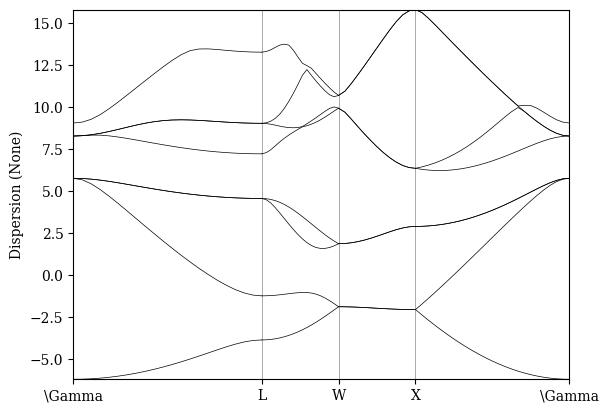

In [36]:
node.outputs.band_structure.show_mpl()

we can plot with sumo - this require the `aiida-user-addons` package which can be installed with

```
pip install https://github.com/SMTG-Bham/aiida-user-addons
```

<module 'matplotlib.pyplot' from '/home/bonan/miniconda3/envs/aiida/lib/python3.12/site-packages/matplotlib/pyplot.py'>

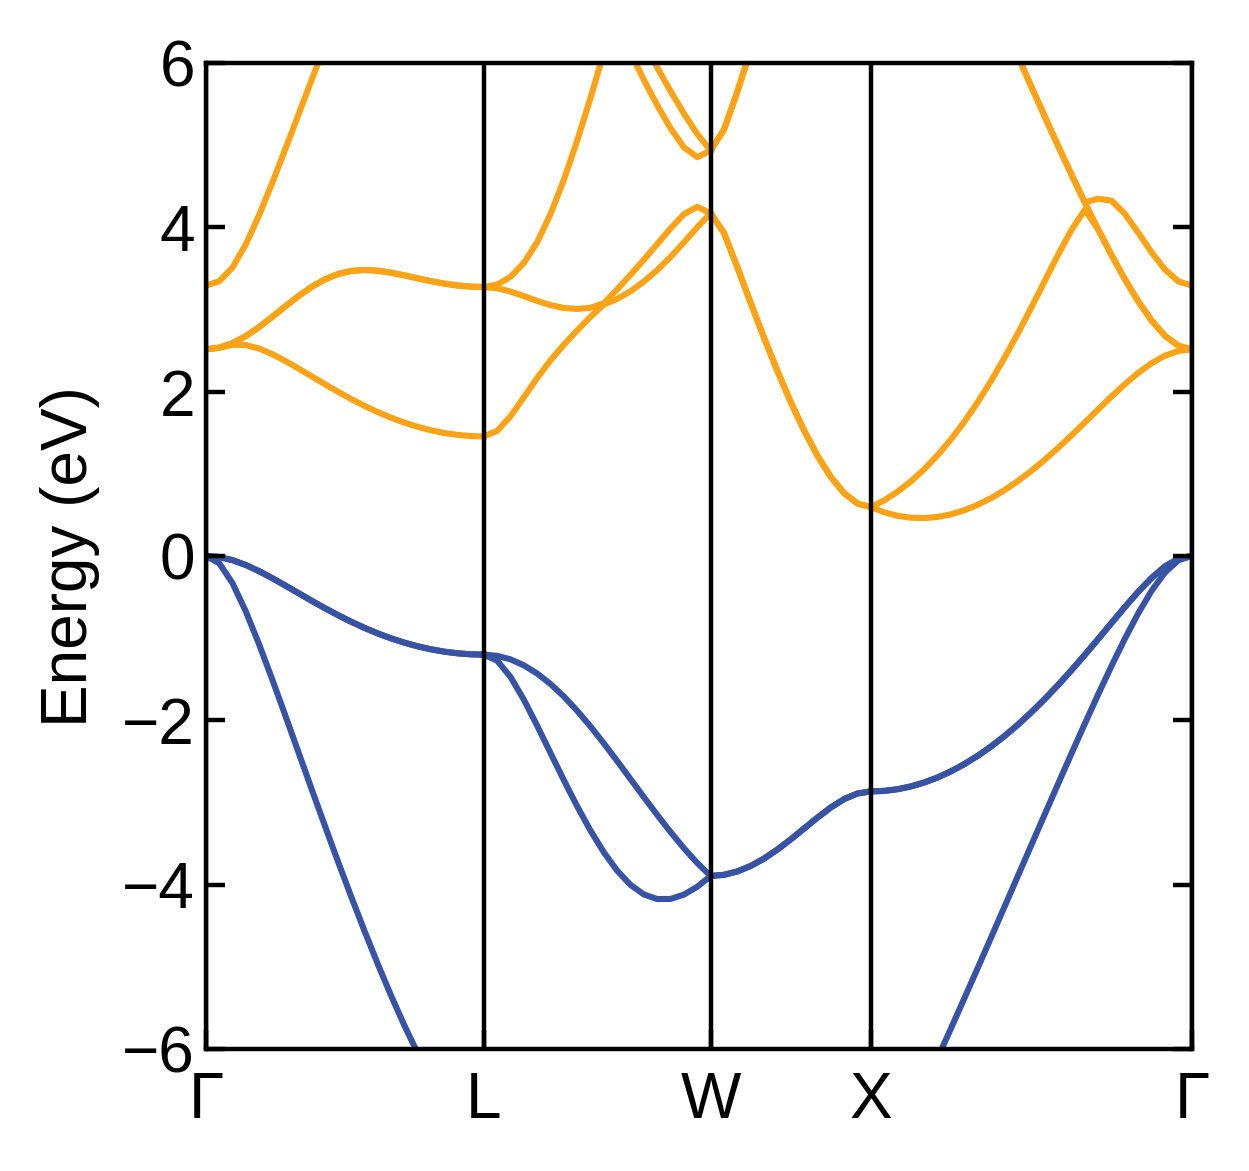

In [67]:
from aiida_user_addons.tools.sumo import get_sumo_bands_plotter

plotter = get_sumo_bands_plotter(node.outputs.band_structure, structure=node.outputs.primitive_structure)
plotter.get_plot()

## Provenance graph

One of the main benefits of using AiiDA is that the provenance all data is stored in a DAG (directed acyclic graph).

The graph can be visualized for inspection.

In [69]:
from aiida.tools.visualization.graph import Graph

/home/bonan/miniconda3/envs/aiida/lib/python3.12/site-packages/aiida/orm/nodes/data/code/legacy.py:183: AiidaDeprecationWarning: `Code.get_description` method is deprecated, use the `description` property instead. (this will be removed in v3)
  warn_deprecation(


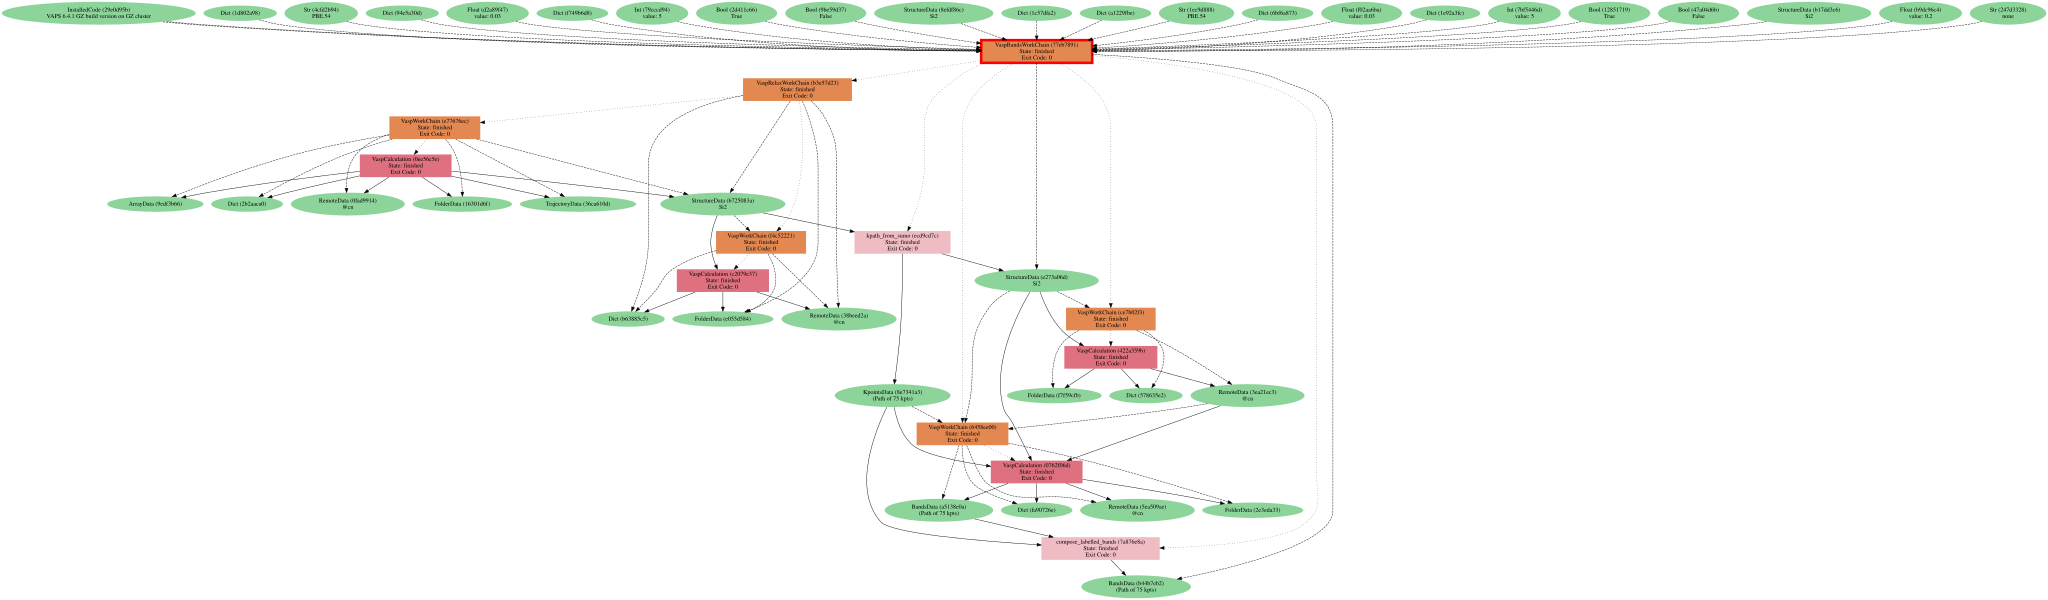

In [70]:
g = Graph(node_id_type='uuid')
g.recurse_descendants(
    node,
)
g.recurse_ancestors(node)
g.graphviz